
# Project : Financial Data Analysis and Visualization

## Overview
As a freelance Data Analyst, I worked with a French financial institution specializing in credit lending. My main tasks were:

* Identify clients who are at the limit of their repayment capacity;
* Calculate the profits realized by the institution, broken down by branch;
* Visualize the evolution of monthly profits throughout 2021, broken down by loan type, and
* Draft a report.


**Database Description**

In the database, each row corresponds to a loan that was granted to one of our clients. Each client is identified by... their ID! We have the following information:
- The city and zip code of the branch where the client contracted the loan
- The client's monthly income
- The monthly payments reimbursed by the client
- The duration of the contracted loan, in number of months
- The type of loan
- And finally, the interest rate


# Summary

* <a href="#C1">Data Import</a>

* <a href="#C2">Variables creation</a>

* <a href="#C3">Number of Clients at the Limit of Their Repayment Capacity</a>

* <a href="#C4">Total profit generated per branch and total number of real estate loans granted</a>

* <a href="#C5">Data visualization</a>




# <a name="C1">Data Import</a>

Let's import necessary librairies

In [ ]:
# Import Python libraries
import numpy as np
import pandas as pd

In [ ]:
loan_data = pd.read_csv("https://raw.githubusercontent.com/OpenClassrooms-Student-Center/fr-4452741-decouvrez-les-librairies-python-pour-la-data-science/main/data/prets.csv")
loan_data.head()

,identifiant,ville,CP,revenu,remboursement,duree,type,taux
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014


Let's rename all variables

In [ ]:
loan_data.rename(columns={'identifiant':'id','revenu':'income','remboursement':'repayment',
                          'ville':'city', 'CP':'postal_code', 'duree':'duration','taux':'rate'},inplace=True)
loan_data.head()

,id,city,postal_code,income,repayment,duration,type,rate
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014


# <a name="C2">Variables creation</a>

1. Creation of the `debt_ratio` variable, a new variable calculating the debt ratio of each individual.
NB: The result is rounded to 2 decimal places.

In [ ]:
loan_data['debt_ratio'] = round(loan_data['repayment'] * 100 / loan_data['income'], 2)
loan_data.head()

,id,city,postal_code,income,repayment,duration,type,rate,debt_ratio
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168,30.80
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701,4.52
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173,23.50
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972,29.50
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014,34.80


2. Let's rename the `rate` variable to `interest_rate` to avoid confusion"""

In [ ]:
loan_data.rename(columns={'rate':'interest_rate'},inplace=True)
loan_data.head()

,id,city,postal_code,income,repayment,duration,type,interest_rate,debt_ratio
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168,30.80
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701,4.52
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173,23.50
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972,29.50
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014,34.80


"""Now let's create two variables as follows:
- `total_cost` corresponding to the total cost of the loan based on the `repayment` and `duration`
- `profits` corresponding to the **monthly profits** realized by the bank on the loan

We will simplify the profit calculation here by:

profits = $\dfrac{C * T}{24} $

avec :
- C = total cost of the loan
- T = interest rate


3. Creation of the `total_cost` variable

In [ ]:
loan_data['total_cost'] = loan_data['repayment'] * loan_data['duration']
loan_data.head()

,id,city,postal_code,income,repayment,duration,type,interest_rate,debt_ratio,total_cost
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168,30.80,271212.0
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701,4.52,15360.0
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173,23.50,374355.0
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972,29.50,132609.6
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014,34.80,105485.4


4. 3. Creation of the `profits` variable

In [ ]:
loan_data['profits'] = round(loan_data['total_cost'] * loan_data['interest_rate'] / 24, 2)

Here are the first 5 rows of the new dataset

In [ ]:
loan_data.head()

,id,city,postal_code,income,repayment,duration,type,interest_rate,debt_ratio,total_cost,profits
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168,30.80,271212.0,13198.98
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701,4.52,15360.0,2368.64
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173,23.50,374355.0,18296.60
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972,29.50,132609.6,5370.69
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014,34.80,105485.4,4456.76


Displaying the 5 loans from which the company generates the most profit. To display them, we use the `.sort_values` method

In [ ]:
loan_data.sort_values('profits', ascending=False).head()

,id,city,postal_code,income,repayment,duration,type,interest_rate,debt_ratio,total_cost,profits
8,7,NICE,6000,5486.0,2956.95,300,immobilier,1.184,53.9,887085.0,43762.86
23,22,NICE,6300,5838.0,3018.25,240,immobilier,1.229,51.7,724380.0,37094.29
186,173,PARIS,75006,6784.0,3744.77,180,immobilier,1.248,55.2,674058.6,35051.05
242,226,PARIS,75002,5098.0,2910.96,240,immobilier,1.140,57.1,698630.4,33184.94
181,168,PARIS,75003,6366.0,2807.41,240,immobilier,1.176,44.1,673778.4,33015.14


# <a name="C3">Number of Clients at the Limit of Their Repayment Capacity</a>

The authorized debt ratio is 35%. Let's determine the number of people who have exceeded this threshold in Paris city. We store the result in a separate variable named `paris_risk_clients`

In [ ]:
paris_risk_clients=loan_data.loc[(loan_data['debt_ratio'] > 35) & (loan_data['city']=='PARIS'),:].shape[0]
print('The number of people who have exceeded this threshold in Paris city is',paris_risk_clients)

The number of people who have exceeded this threshold in Paris city is 16


To facilitate the processing of potential future loan applications, let's add a variable named `risk` which would have the value `Yes` if the client is at risk (`debt_ratio` > 35%), `No` otherwise

In [ ]:
loan_data['risk'] = 'No'
loan_data.loc[loan_data['debt_ratio'] > 35, 'risk'] = 'Yes'
loan_data.head(12)

,id,city,postal_code,income,repayment,duration,type,interest_rate,debt_ratio,total_cost,profits,risk
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168,30.80,271212.0,13198.98,No
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701,4.52,15360.0,2368.64,No
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173,23.50,374355.0,18296.60,No
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972,29.50,132609.6,5370.69,No
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014,34.80,105485.4,4456.76,No
5,4,MARSEILLE,13012,1476.0,423.61,240,immobilier,1.209,28.70,101666.4,5121.44,No
6,5,PARIS,75016,2476.0,836.89,240,immobilier,1.116,33.80,200853.6,9339.69,No
7,6,LYON,69008,1867.0,711.33,240,immobilier,1.196,38.10,170719.2,8507.51,Yes
8,7,NICE,6000,5486.0,2956.95,300,immobilier,1.184,53.90,887085.0,43762.86,Yes
9,8,BORDEAUX,33200,3578.0,751.38,180,immobilier,1.316,21.00,135248.4,7416.12,No


Given that in the database, some clients have taken out several loans with the institution, this would likely skew the calculations.
To avoid this,
* we create a dataframe where there is only one row per client, with a summary of their information (sum of `repayment`, `debt_ratio`, `total_cost`, and `profits`).



In [ ]:
customer_profil=loan_data.groupby('id')[['repayment','debt_ratio','total_cost','profits']].sum()
customer_profil.head()

,repayment,debt_ratio,total_cost,profits
id,,,,
0,1130.05,30.80,271212.0,13198.98
1,1487.85,28.02,389715.0,20665.24
2,552.54,29.50,132609.6,5370.69
3,586.03,34.80,105485.4,4456.76
4,423.61,28.70,101666.4,5121.44


In [ ]:
customer_profil=customer_profil.reset_index()
customer_profil.head()

,id,repayment,debt_ratio,total_cost,profits
0,0,1130.05,30.80,271212.0,13198.98
1,1,1487.85,28.02,389715.0,20665.24
2,2,552.54,29.50,132609.6,5370.69
3,3,586.03,34.80,105485.4,4456.76
4,4,423.61,28.70,101666.4,5121.44


# <a name="C4">Total profit generated per branch and total number of real estate loans granted</a>

Let's calculate the total monthly profit realized by the Toulouse branch

In [ ]:
toulouse_profit=round(loan_data.loc[loan_data['city']=='TOULOUSE','profits'].sum(),2) # ccreation of the list ; toulouse_profit
print('The total monthly profit realized by the Toulouse branch is',toulouse_profit,'€')

The total monthly profit realized by the Toulouse branch is 213805.56 €


Let's determine the number of car loans granted and their average total cost

In [ ]:
car_loans_granted=loan_data.loc[loan_data['type']=='automobile',:]
print('We granted',car_loans_granted.shape[0], 'car loans, whose average total cost is',car_loans_granted['total_cost'].mean(),'€')

We granted 16 car loans, whose average total cost is 13665.0 €


Let's recalculate the exact number of people in a risky financial situation based on the debt ratio

In [ ]:
number_people_risk = customer_profil.loc[loan_data['debt_ratio'] > 35,:].shape[0]
print('The number of people in a risky financial situation is',number_people_risk)

The number of people in a risky financial situation is 54


Let's calculate the profit generated by each of our branches

In [ ]:
loan_data.groupby('city')['profits'].sum().reset_index()

,city,profits
0,BORDEAUX,168132.13
1,LYON,301478.15
2,MARSEILLE,439591.17
3,NICE,268273.64
4,PARIS,1001633.02
5,TOULOUSE,213805.56


Let's calculate the profit generated by each of our branches, broken down by loan type.

In [ ]:
loan_data.pivot_table(index='city',columns='type',values='profits',aggfunc='sum')
# The city of BORDEAUX did not record any car loans

type,automobile,immobilier
city,,
BORDEAUX,NaN,168132.13
LYON,4738.05,296740.10
MARSEILLE,6135.59,433455.58
NICE,3114.55,265159.09
PARIS,9949.51,991683.51
TOULOUSE,6121.97,207683.59


Let's determine which city seems the most interesting for developing mortgage loans

In [ ]:
d_loan_data=loan_data.pivot_table(index='city',columns='type',values='profits',aggfunc='mean').reset_index()
d_loan_data.sort_values(by='immobilier',ascending=False)

type,city,automobile,immobilier
3,NICE,1557.275000,13955.741579
4,PARIS,1989.902000,13773.382083
1,LYON,1579.350000,11869.604000
0,BORDEAUX,NaN,10508.258125
5,TOULOUSE,2040.656667,8653.482917
2,MARSEILLE,2045.196667,6020.216389


Database merge operation.
We have 2 databases that need to be merged to form a single one.

* Let's import the 2 client databases


In [ ]:
customers_1 = pd.read_csv('https://raw.githubusercontent.com/OpenClassrooms-Student-Center/fr-4452741-decouvrez-les-librairies-python-pour-la-data-science/main/data/clients.csv')
customers_1.head()

,identifiant,email,nom,genre
0,0,LaurentDagenais@rhyta.com,Laurent Dagenais,M
1,1,GuyMarois@fleckens.hu,Guy Marois,M
2,2,BeaufortLesage@einrot.com,Beaufort Lesage,M
3,3,RussellDurand@armyspy.com,Russell Durand,M
4,4,AlexisRiel@rhyta.com,Alexis Riel,M


In [ ]:
customers_1.shape # number of rows and colomns inthe dataset

(150, 4)

In [ ]:
customers_2 = pd.read_csv('https://raw.githubusercontent.com/OpenClassrooms-Student-Center/fr-4452741-decouvrez-les-librairies-python-pour-la-data-science/main/data/clients_suite.csv')
customers_2.head()

,identifiant,email,nom,genre
0,150,RochMireault@gustr.com,Roch Mireault,M
1,151,NathalieCormier@cuvox.de,Nathalie Cormier,F
2,152,VallisMainville@gustr.com,Vallis Mainville,M
3,153,DanielleNeufville@teleworm.us,Danielle Neufville,F
4,154,AllyrianeRacine@gustr.com,Allyriane Racine,F


In [ ]:
customers_2.shape

(78, 4)

Now let's merge the two dataframes `customers_1` and `customers_2` into one large `customers` dataframe that will contain all of our customer information!

In [ ]:
customers=pd.concat([customers_1,customers_2],ignore_index='True')
customers.head()

,identifiant,email,nom,genre
0,0,LaurentDagenais@rhyta.com,Laurent Dagenais,M
1,1,GuyMarois@fleckens.hu,Guy Marois,M
2,2,BeaufortLesage@einrot.com,Beaufort Lesage,M
3,3,RussellDurand@armyspy.com,Russell Durand,M
4,4,AlexisRiel@rhyta.com,Alexis Riel,M


In [ ]:
customers.rename(columns={'identifiant':'id'},inplace=True)
customers.head()

,id,email,nom,genre
0,0,LaurentDagenais@rhyta.com,Laurent Dagenais,M
1,1,GuyMarois@fleckens.hu,Guy Marois,M
2,2,BeaufortLesage@einrot.com,Beaufort Lesage,M
3,3,RussellDurand@armyspy.com,Russell Durand,M
4,4,AlexisRiel@rhyta.com,Alexis Riel,M


Now, let's merge this `customers` file with the client profiles `customers_profil` created previously. The final dataframe will be `data`

Visualization of the 2 files

In [ ]:
customer_profil.shape

(228, 5)

In [ ]:
customers.shape

(228, 4)

In [ ]:
data=pd.merge(customers,customer_profil,on='id', how='inner')
data.head()

,id,email,nom,genre,repayment,debt_ratio,total_cost,profits
0,0,LaurentDagenais@rhyta.com,Laurent Dagenais,M,1130.05,30.80,271212.0,13198.98
1,1,GuyMarois@fleckens.hu,Guy Marois,M,1487.85,28.02,389715.0,20665.24
2,2,BeaufortLesage@einrot.com,Beaufort Lesage,M,552.54,29.50,132609.6,5370.69
3,3,RussellDurand@armyspy.com,Russell Durand,M,586.03,34.80,105485.4,4456.76
4,4,AlexisRiel@rhyta.com,Alexis Riel,M,423.61,28.70,101666.4,5121.44


# <a name="C5">Data visualization</a>

`Context` : As part of the monthly reporting, I am asked to visualize the evolution of monthly profits throughout 2021, broken down by loan type. The database made available to me is the following:

In [ ]:
CA = pd.read_csv('https://raw.githubusercontent.com/OpenClassrooms-Student-Center/fr-4452741-decouvrez-les-librairies-python-pour-la-data-science/main/data/CA.csv')
CA['date'] = pd.to_datetime(CA['date'])
CA

,date,immobilier,automobile,consommation
0,2021-01-01,10439,5096,3808
1,2021-02-01,11266,5146,5838
2,2021-03-01,11315,5276,5601
3,2021-04-01,11456,5067,3639
4,2021-05-01,10816,4937,5273
5,2021-06-01,11988,5026,4133
6,2021-07-01,11267,5228,5253
7,2021-08-01,10179,5462,4822
8,2021-09-01,10627,4698,5099
9,2021-10-01,10082,5825,2002


The code below allowed me to visualize the evolution of net monthly profits throughout 2021, broken down by loan type

In [ ]:
import matplotlib.pyplot as plt

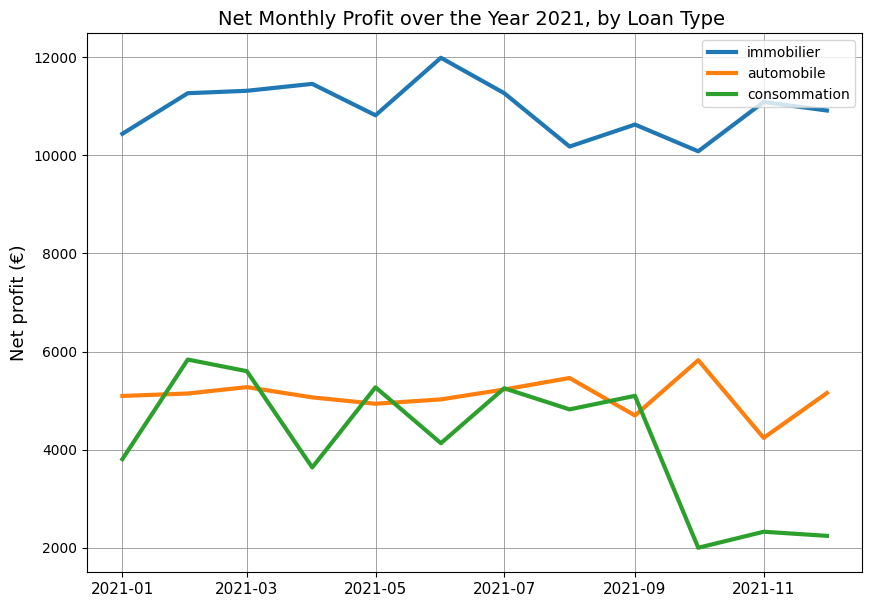

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(CA['date'], CA['immobilier'], label='immobilier',linewidth=3)
plt.plot(CA['date'], CA['automobile'], label='automobile', linewidth=3)
plt.plot(CA['date'], CA['consommation'], label='consommation',linewidth=3)
plt.title("Net Monthly Profit over the Year 2021, by Loan Type ", fontsize=14)
plt.ylabel("Net profit (€)", fontsize=13)
plt.legend(loc='upper right')
plt.grid(color='grey',linestyle='-', linewidth=0.5)
plt.xticks(fontsize=11)
plt.show()